# The score didn't move. What did?

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/llmops-genai-platform/model-migration-diff/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=llmops-genai-platform/model-migration-diff/demo.ipynb)

A team swaps model A for model B, runs the same 400-case eval set once under each, and the score reads
88.3% both times. This notebook shows, exactly, that two very different migrations produce that same
number - and which comparison can tell them apart.

1. Calibration - exact probabilities vs raw simulated runs
2. Four migrations, five gates
3. The sweep - McNemar gets quieter as churn grows
4. Negative result - slicing by intent does not detect a spread regression
5. Try your own

## The engine

Extracted from `migrate.py` at build time, character for character. Per case, A passes with probability
pa and B with pb. Each case adds (1, 0) - broke - or (0, 1) - fixed - or nothing, so the joint
distribution of (broke, fixed) is a 2D convolution over cases. Every gate is a function of that pair,
so its firing rate is an exact sum over the table.

In [1]:
from __future__ import annotations

from functools import lru_cache
from typing import Dict, List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

ALPHA = 0.05


MARGIN = 0.02  # "within 2 points" for the score-delta and TOST gates


INTENTS: Tuple[Tuple[str, int], ...] = (
    ("billing", 80), ("account", 70), ("shipping", 60), ("product", 50),
    ("returns", 50), ("tech", 40), ("refunds", 30), ("legal", 20),
)


N = sum(s for _, s in INTENTS)


FLAKY_SHARE, FAIL_SHARE = 0.08, 0.07  # per intent; the rest are stable passes


STABLE_P = 0.995  # a stable pass still fails 1 run in 200


N_SWAP = 20  # cases a migration breaks, and (net-zero scenarios) cases it fixes


CONCENTRATE_IN = "refunds"


SEED = 2026


SCENARIOS = ("no change", "net zero, concentrated", "net zero, spread", "plain regression")


GATES = ("score delta", "mcnemar", "tost", "per-intent", "churn vs rerun")


MC_REPS = 20000


def eval_set(seed: int = SEED) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """(pa, intent index, kind) per case. kind: 0 stable pass, 1 stable fail, 2 flaky ~ Beta(2, 2)."""
    rng = np.random.default_rng(seed)
    pa, intent, kind = [], [], []
    for j, (_, size) in enumerate(INTENTS):
        nf, nx = round(FLAKY_SHARE * size), round(FAIL_SHARE * size)
        kinds = [2] * nf + [1] * nx + [0] * (size - nf - nx)
        for k in kinds:
            pa.append(rng.beta(2, 2) if k == 2 else (STABLE_P if k == 0 else 1 - STABLE_P))
            intent.append(j)
            kind.append(k)
    return np.array(pa), np.array(intent), np.array(kind)


def _round_robin(mask: np.ndarray, intent: np.ndarray, n: int) -> np.ndarray:
    """n case indices from `mask`, taken one intent at a time so the change is spread, not clumped."""
    pools = [list(np.flatnonzero(mask & (intent == j))) for j in range(len(INTENTS))]
    out: List[int] = []
    while len(out) < n:
        took = False
        for p in pools:
            if p and len(out) < n:
                out.append(p.pop(0))
                took = True
        if not took:
            raise ValueError("not enough eligible cases")
    return np.array(out)


def scenario(name: str, pa: np.ndarray, intent: np.ndarray, kind: np.ndarray,
             n_swap: int = N_SWAP) -> Tuple[np.ndarray, np.ndarray]:
    """(pb, changed). Breaks turn stable passes into stable fails; fixes do the reverse."""
    pb, changed = pa.copy(), np.zeros(len(pa), dtype=bool)
    if name == "no change":
        return pb, changed
    conc = [n for n, _ in INTENTS].index(CONCENTRATE_IN)
    if name == "net zero, concentrated":
        breaks = np.flatnonzero((kind == 0) & (intent == conc))[:n_swap]
    else:
        breaks = _round_robin(kind == 0, intent, n_swap)
    fixes = _round_robin((kind == 1) & (intent != conc), intent, n_swap) if name.startswith("net zero") else []
    if len(breaks) < n_swap:
        raise ValueError("concentrated intent has too few stable passes")
    pb[breaks], pb[fixes] = 1 - STABLE_P, STABLE_P
    changed[breaks], changed[fixes] = True, True
    return pb, changed


def joint_pmf(pa: np.ndarray, pb: np.ndarray) -> np.ndarray:
    """pmf[broke, fixed], exact, by 2D convolution over cases."""
    n = len(pa)
    pmf = np.zeros((n + 1, n + 1))
    pmf[0, 0] = 1.0
    for a, b in zip(pa, pb):
        p_broke, p_fixed = a * (1 - b), (1 - a) * b
        new = (1 - p_broke - p_fixed) * pmf
        new[1:, :] += p_broke * pmf[:-1, :]
        new[:, 1:] += p_fixed * pmf[:, :-1]
        pmf = new
    return pmf


@lru_cache(maxsize=None)
def mcnemar_p(n: int) -> np.ndarray:
    """Exact two-sided McNemar p-value for every (broke, fixed) with broke + fixed <= n."""
    b, f = np.meshgrid(np.arange(n + 1), np.arange(n + 1), indexing="ij")
    m = b + f
    p = np.minimum(1.0, 2 * stats.binom.cdf(np.minimum(b, f), np.maximum(m, 1), 0.5))
    return np.where(m == 0, 1.0, p)


def reject(gate: str, n: int) -> np.ndarray:
    """Boolean table over (broke, fixed) for the whole-set gates. TOST returns 'certified equivalent'."""
    b, f = np.meshgrid(np.arange(n + 1), np.arange(n + 1), indexing="ij")
    d = (f - b) / n
    if gate == "score delta":
        return np.abs(d) > MARGIN
    if gate == "mcnemar":
        return mcnemar_p(n) < ALPHA
    if gate == "tost":
        se = np.sqrt(np.maximum((b + f) / n - d ** 2, 0) / n)
        z = stats.norm.isf(ALPHA)
        return (d - z * se > -MARGIN) & (d + z * se < MARGIN)
    raise ValueError(gate)


def churn_pmf(pa: np.ndarray, pb: np.ndarray) -> np.ndarray:
    """Exact pmf of churn = broke + fixed (a 1D Poisson-binomial: each case differs with prob pa(1-pb)+pb(1-pa))."""
    pmf = np.array([1.0])
    for q in pa * (1 - pb) + pb * (1 - pa):
        pmf = np.convolve(pmf, [1 - q, q])
    return pmf


def churn_threshold(pa: np.ndarray) -> int:
    """Oracle only: smallest T with P(churn >= T) <= ALPHA when B is A run again. Needs the true pa."""
    tail = np.cumsum(churn_pmf(pa, pa)[::-1])[::-1]
    return int(np.argmax(tail <= ALPHA))


def rerun_pmf(pa: np.ndarray, pb: np.ndarray) -> np.ndarray:
    """pmf[odd_b, odd_r] over cases: odd_b = A and A' agree and B differs; odd_r = A and B agree and A' differs."""
    n = len(pa)
    pmf = np.zeros((n + 1, n + 1))
    pmf[0, 0] = 1.0
    for a, b in zip(pa, pb):
        p_b = a * a * (1 - b) + (1 - a) ** 2 * b
        p_r = a * b * (1 - a) + (1 - a) * (1 - b) * a
        new = (1 - p_b - p_r) * pmf
        new[1:, :] += p_b * pmf[:-1, :]
        new[:, 1:] += p_r * pmf[:, :-1]
        pmf = new
    return pmf


@lru_cache(maxsize=None)
def sign_reject(n: int) -> np.ndarray:
    """reject[odd_b, odd_r]: one-sided exact sign test, B odd one out more often than chance."""
    x, y = np.meshgrid(np.arange(n + 1), np.arange(n + 1), indexing="ij")
    return (x + y > 0) & (stats.binom.sf(x - 1, x + y, 0.5) < ALPHA)


def gate_probs(pa: np.ndarray, pb: np.ndarray, intent: np.ndarray) -> Dict[str, float]:
    """Exact P(gate fires) for every gate (P(certified) for tost)."""
    n = len(pa)
    pmf = joint_pmf(pa, pb)
    out = {g: float((pmf * reject(g, n)).sum()) for g in ("score delta", "mcnemar", "tost")}
    out["churn vs rerun"] = float((rerun_pmf(pa, pb) * sign_reject(n)).sum())
    quiet = 1.0
    for j in range(len(INTENTS)):
        m = intent == j
        pj = joint_pmf(pa[m], pb[m])
        quiet *= 1 - float((pj * (mcnemar_p(int(m.sum())) < ALPHA / len(INTENTS))).sum())
    out["per-intent"] = 1 - quiet
    return out


def evaluate() -> Dict:
    """Every scenario: true change, expected counts, per-intent pass rates, and every gate's firing rate."""
    pa, intent, kind = eval_set()
    t = churn_threshold(pa)
    rows = []
    for sc in SCENARIOS:
        pb, changed = scenario(sc, pa, intent, kind)
        p_broke, p_fixed = pa * (1 - pb), (1 - pa) * pb
        rows.append({
            "scenario": sc, "cases_changed": int(changed.sum()),
            "score_a": float(pa.mean()), "score_b": float(pb.mean()),
            "expected_broke": float(p_broke.sum()), "expected_fixed": float(p_fixed.sum()),
            "expected_churn": float((p_broke + p_fixed).sum()),
            "intent_scores": {n: [float(pa[intent == j].mean()), float(pb[intent == j].mean())]
                              for j, (n, _) in enumerate(INTENTS)},
            "gates": gate_probs(pa, pb, intent),
        })
    noise = float((2 * pa * (1 - pa)).sum())
    return {"churn_threshold": t, "noise_churn": noise, "scenarios": rows}


def sweep(swaps: Sequence[int] = tuple(range(0, 21, 2))) -> List[Dict]:
    """Net-zero spread migration of size k (k breaks + k fixes): which gates see it as k grows."""
    pa, intent, kind = eval_set()
    out = []
    for k in swaps:
        pb, _ = scenario("net zero, spread", pa, intent, kind, k) if k else (pa.copy(), None)
        out.append({"swap": int(k), "churn_cases": 2 * int(k), **gate_probs(pa, pb, intent)})
    return out


def decide(a: np.ndarray, b: np.ndarray, r: np.ndarray, intent: np.ndarray) -> Dict[str, np.ndarray]:
    """Gate decisions on simulated (reps x cases) 0/1 runs of A, B and A' - the raw-rule check on the exact engine."""
    n = a.shape[1]
    broke, fixed = a & ~b, ~a & b
    nb, nf = broke.sum(axis=1), fixed.sum(axis=1)
    out = {g: reject(g, n)[nb, nf] for g in ("score delta", "mcnemar", "tost")}
    out["churn vs rerun"] = sign_reject(n)[((a == r) & (b != a)).sum(axis=1), ((a == b) & (r != a)).sum(axis=1)]
    any_int = np.zeros(len(b), dtype=bool)
    for j in range(len(INTENTS)):
        m = intent == j
        bj, fj = broke[:, m].sum(axis=1), fixed[:, m].sum(axis=1)
        any_int |= mcnemar_p(int(m.sum()))[bj, fj] < ALPHA / len(INTENTS)
    out["per-intent"] = any_int
    return out


def simulate(pa: np.ndarray, pb: np.ndarray, reps: int, seed: int = 7) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Raw runs: A, B, and a rerun of A."""
    rng = np.random.default_rng(seed)
    return tuple(rng.random((reps, len(pa))) < p for p in (pa, pb, pa))


def wilson(k: int, n: int, z: float = float(stats.norm.isf(0.005))) -> List[float]:
    p = k / n
    den = 1 + z * z / n
    mid = (p + z * z / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return [float(mid - half), float(mid + half)]


def calibrate(reps: int = MC_REPS) -> Dict:
    """Exact gate rates vs raw simulated runs; and the 2D convolution vs scipy where it has a closed form."""
    pa, intent, kind = eval_set()
    rows = []
    for sc in SCENARIOS:
        pb, _ = scenario(sc, pa, intent, kind)
        ex = gate_probs(pa, pb, intent)
        dec = decide(*simulate(pa, pb, reps), intent)
        for g in GATES:
            hits = int(dec[g].sum())
            lo, hi = wilson(hits, reps)
            rows.append({"scenario": sc, "gate": g, "exact": ex[g], "mc": hits / reps, "inside_99": bool(lo <= ex[g] <= hi)})
    # A always passes, B passes w.p. 0.3: broke ~ Binom(40, 0.7) and fixed is always 0.
    pmf = joint_pmf(np.ones(40), np.full(40, 0.3))
    gap = float(np.max(np.abs(pmf[:, 0] - stats.binom.pmf(np.arange(41), 40, 0.7))))
    return {"rates": rows, "conv_vs_binom_gap": gap, "fixed_mass_off_zero": float(pmf[:, 1:].sum())}


def audit(rows: Sequence[Tuple[str, int, int]], rerun: Sequence[int] = ()) -> Dict:
    """The app's core. rows: (intent, A result, B result) per case, 0/1, one run each.

    rerun (optional): a second run of model A on the same cases. With it, the churn A-vs-B is tested
    against the churn A-vs-A' by the exact sign test. Returns the score change, broke/fixed/churn, the
    McNemar p, the per-intent table and the rerun comparison.
    """
    if not rows:
        raise ValueError("no cases")
    names = [r[0] for r in rows]
    a = np.array([r[1] for r in rows], dtype=int)
    b = np.array([r[2] for r in rows], dtype=int)
    if not (np.isin(a, (0, 1)).all() and np.isin(b, (0, 1)).all()):
        raise ValueError("results must be 0 or 1")
    n = len(a)
    broke, fixed = int(((a == 1) & (b == 0)).sum()), int(((a == 0) & (b == 1)).sum())
    labels = list(dict.fromkeys(names))
    per = []
    for lab in labels:
        m = np.array([x == lab for x in names])
        bj, fj = int(((a == 1) & (b == 0) & m).sum()), int(((a == 0) & (b == 1) & m).sum())
        per.append({"intent": lab, "n": int(m.sum()), "a": float(a[m].mean()), "b": float(b[m].mean()),
                    "broke": bj, "fixed": fj, "p": float(mcnemar_p(int(m.sum()))[bj, fj]),
                    "flag": bool(mcnemar_p(int(m.sum()))[bj, fj] < ALPHA / len(labels))})
    out = {"n": n, "score_a": float(a.mean()), "score_b": float(b.mean()), "broke": broke, "fixed": fixed,
           "churn": broke + fixed, "mcnemar_p": float(mcnemar_p(n)[broke, fixed]), "intents": per,
           "noise_churn": None, "odd_b": None, "odd_r": None, "sign_p": None}
    if len(rerun):
        r = np.asarray(rerun, dtype=int)
        if r.shape != a.shape or not np.isin(r, (0, 1)).all():
            raise ValueError("rerun must be one 0/1 per case")
        ob, orr = int(((a == r) & (b != a)).sum()), int(((a == b) & (r != a)).sum())
        out.update(noise_churn=int((a != r).sum()), odd_b=ob, odd_r=orr,
                   sign_p=float(stats.binom.sf(ob - 1, ob + orr, 0.5)) if ob + orr else 1.0)
    return out

print('engine loaded')

engine loaded


**Resolution of the instrument.** Every gate number here is exact and matches `evidence.txt` to the digit.
Only the calibration's raw simulation runs at 4,000 replicates instead of the study's 20,000.

## 1. Calibration

In [2]:
cal = calibrate(4000)
print(f"2D convolution vs scipy binom: max gap {cal['conv_vs_binom_gap']:.1e}")
print(f"gate rates inside their 99% interval: {sum(r['inside_99'] for r in cal['rates'])} of {len(cal['rates'])}")

2D convolution vs scipy binom: max gap 2.9e-16
gate rates inside their 99% interval: 20 of 20


## 2. Four migrations, five gates

In [3]:
ev = evaluate()
print(f"noise churn, A vs A run again: {ev['noise_churn']:.2f} cases")
for r in ev["scenarios"]:
    g = r["gates"]
    print(f"{r['scenario']:<24} score {r['score_a']:.1%} -> {r['score_b']:.1%}  changed {r['cases_changed']:>2}  "
          + "  ".join(f"{k} {g[k]:.3f}" for k in GATES))
print("refunds under the concentrated migration:", [round(x, 3) for x in ev["scenarios"][1]["intent_scores"]["refunds"]])

noise churn, A vs A run again: 17.47 cases
no change                score 88.3% -> 88.3%  changed  0  score delta 0.041  mcnemar 0.029  tost 0.222  per-intent 0.000  churn vs rerun 0.032
net zero, concentrated   score 88.3% -> 88.3%  changed 40  score delta 0.041  mcnemar 0.000  tost 0.000  per-intent 1.000  churn vs rerun 1.000
net zero, spread         score 88.3% -> 88.3%  changed 40  score delta 0.041  mcnemar 0.000  tost 0.000  per-intent 0.000  churn vs rerun 1.000
plain regression         score 88.3% -> 83.3%  changed 20  score delta 0.997  mcnemar 0.949  tost 0.000  per-intent 0.002  churn vs rerun 0.978
refunds under the concentrated migration: [0.879, 0.219]


Two migrations post the same 88.3%. One breaks 20 of the 30 refunds cases (88% -> 22%) and fixes 20
cases elsewhere; the other spreads the same 40 changes thinly. The score-delta gate fires 4% of the time
on both - exactly its rate on no change at all. McNemar, the textbook paired test, is quieter on them
(0.0001) than on no change (0.029), because it compares broke with fixed and they balance.

Two gates see them. Per-intent McNemar finds the concentrated one and is blind to the spread one. The
churn test - run A a second time, and ask whether B disagrees with A more often than A disagrees with
itself - catches both, at 3.2% false alarms and 1.5x the calls.

TOST equivalence is not fooled: the paired variance *is* churn / N, so churn widens the interval and it
refuses to certify. But on 400 cases it certifies an unchanged model only 22% of the time, so "not
certified" carries little news.

## 3. The sweep

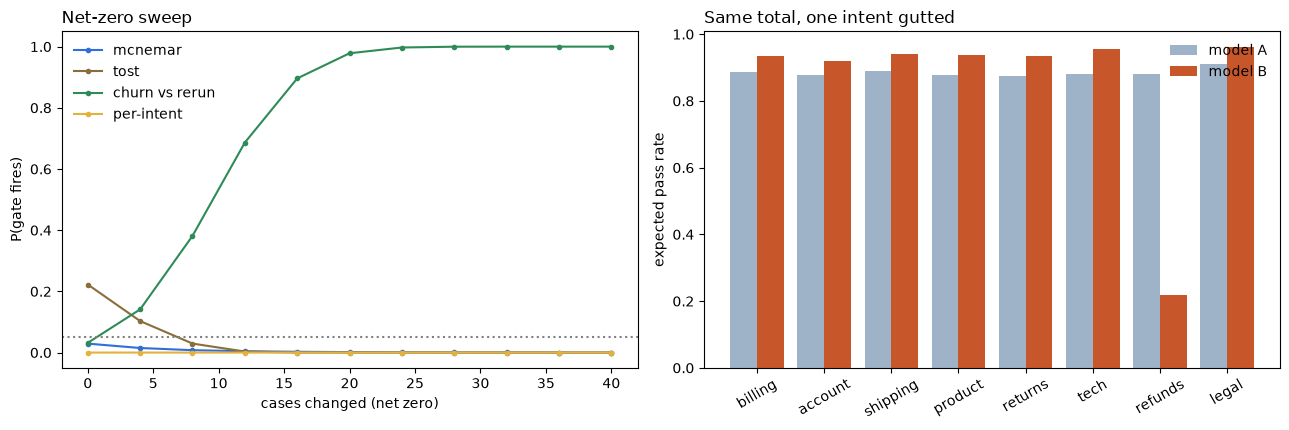

changed  0   mcnemar 0.0292   churn vs rerun 0.032
changed  8   mcnemar 0.0078   churn vs rerun 0.381
changed 16   mcnemar 0.0026   churn vs rerun 0.896
changed 24   mcnemar 0.0010   churn vs rerun 0.997
changed 32   mcnemar 0.0003   churn vs rerun 1.000
changed 40   mcnemar 0.0001   churn vs rerun 1.000


In [4]:
sw = sweep()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for g, col in (("mcnemar", "#2f6fdb"), ("tost", "#8a6d3b"), ("churn vs rerun", "#2e8b57"), ("per-intent", "#e3b23c")):
    axes[0].plot([r["churn_cases"] for r in sw], [r[g] for r in sw], "o-", color=col, ms=3, label=g)
axes[0].axhline(ALPHA, color="grey", ls=":"); axes[0].legend(frameon=False)
axes[0].set_xlabel("cases changed (net zero)"); axes[0].set_ylabel("P(gate fires)"); axes[0].set_title("Net-zero sweep", loc="left")
names = [n for n, _ in INTENTS]
conc = ev["scenarios"][1]["intent_scores"]
axes[1].bar(np.arange(len(names)) - 0.2, [conc[n][0] for n in names], 0.4, color="#9fb3c8", label="model A")
axes[1].bar(np.arange(len(names)) + 0.2, [conc[n][1] for n in names], 0.4, color="#c8562b", label="model B")
axes[1].set_xticks(range(len(names))); axes[1].set_xticklabels(names, rotation=30)
axes[1].set_ylabel("expected pass rate"); axes[1].legend(frameon=False); axes[1].set_title("Same total, one intent gutted", loc="left")
plt.tight_layout(); plt.savefig("notebook_chart.png", dpi=120); plt.show()
for r in sw[::2]:
    print(f"changed {r['churn_cases']:>2}   mcnemar {r['mcnemar']:.4f}   churn vs rerun {r['churn vs rerun']:.3f}")

## 4. Negative result - slicing by intent

In [5]:
pr = ev["scenarios"][3]["gates"]
print(f"plain regression, 20 breaks spread: whole-set McNemar {pr['mcnemar']:.3f}   per-intent Bonferroni {pr['per-intent']:.3f}")

plain regression, 20 breaks spread: whole-set McNemar 0.949   per-intent Bonferroni 0.002


Each intent sees 2 or 3 breaks; an exact test at 0.05 / 8 needs about 8. The same regression the
whole-set test catches 95% of the time is caught 0.2% of the time by slicing. Slice to *diagnose* a
change you have already detected, not to detect one.

## Summary

| claim | what the numbers say |
|---|---|
| "the score didn't move, so nothing changed" | 40 of 400 cases changed; refunds went 88% -> 22% |
| "McNemar is the right paired test" | it is a test of net change; on a net-zero swap it is quieter than on no change |
| "slice the eval by intent" | finds a concentrated break, misses spread ones (0.002 vs 0.949) |
| "run the old model twice" | the exact sign test catches both swaps at 3.2% false alarms, 1.5x calls |

## 5. Try your own

In [6]:
# rows  = [("refunds", 1, 0), ("refunds", 1, 0), ("billing", 0, 1), ("billing", 1, 1)]   # intent, A, B
# rerun = [1, 1, 0, 1]                                                                  # A run again
# res = audit(rows, rerun)
# print(res["broke"], res["fixed"], res["mcnemar_p"], res["sign_p"])
print("uncomment to explore")

uncomment to explore


---

**Built by Phoebe Fu** - one mini product a day. [Repo](https://github.com/phoebefu6/phoebe-the-builder) ·
[This build](llmops-genai-platform/model-migration-diff)

Streamlit version, where you paste your own per-case results:

```bash
pip install -r requirements.txt
streamlit run app.py
```

Sibling builds: [`prompt-regression-ci`](../prompt-regression-ci) asks how often a prompt gate goes red on
noise; [`golden-set-builder`](../golden-set-builder) asks whether the eval set still represents traffic.